
# PART 2


# Exploratory Data Analysis (EDA)

**Objective:** Understand relationships between key variables (age, BMI, smoker, region) and **annual_medical_cost**.  
**Goal:** Identify top cost drivers and patterns to prepare for predictive modeling.


**Executive Question:** *What pricing strategy should Allianz use for different U.S. customer segments to be fair and profitable?*

**Hypotheses (to be tested):**
- H1: Smoking significantly increases medical annual_medical_cost.
- H2: Higher BMI leads to higher medical annual_medical_cost.
- H3: Age is positively correlated with annual_medical_cost.
- H4: Individuals with chronic diseases have higher annual medical costs.
- H5: Individuals with more hospitalizations over the past 3 years have higher annual medical costs.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:


# Load your cleaned CSV 
df = pd.read_csv(r"C:\Users\sruth\Documents\Greenbootcamps\Med_Insurance_Finalproject\Data\medical_insurance_clean.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,bmi_band,age_band
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,2,0,1,0,0,Overweight,45-54
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,0,0,1,0,1,1,0,Overweight,65+
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,1,1,0,2,1,0,1,0,Obese I,65+
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,1,0,0,1,0,0,0,Obese I,<25
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,2,0,1,1,0,1,0,Obese I,45-54


In [18]:
df.shape

(100000, 56)

In [19]:
df.isna().any().sum()

np.int64(0)

In [20]:
df.duplicated().sum()

np.int64(0)

# 🧩 Hypothesis 1

    H₁: Individuals who smoke will have higher annual medical costs than non-smokers, due to elevated health risks and higher incidence of chronic diseases.

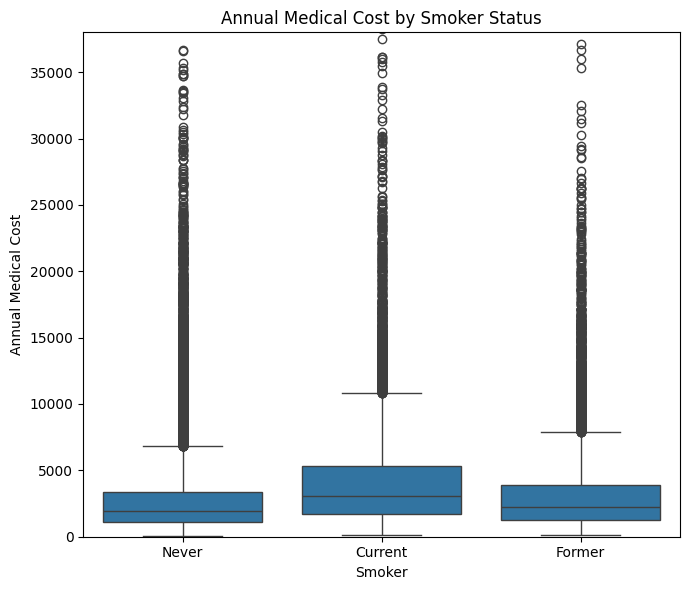

In [21]:
# 4.1 Annual medical cost by smoker status

if {'smoker', 'annual_medical_cost'}.issubset(df.columns):
    plt.figure(figsize=(7,6))
    sns.boxplot(data=df, x='smoker', y='annual_medical_cost')
    plt.title("Annual Medical Cost by Smoker Status")
    plt.xlabel("Smoker"); plt.ylabel("Annual Medical Cost")
    plt.ylim(0, 38000)  # 👈 Zoom in
    plt.tight_layout(); plt.show()
else:
    print("Columns needed not found: 'smoker' and/or 'annual_medical_cost'")

📈 Visual Interpretation

From your output:

Each group (Never, Current, Former) shows right-skewed distributions (many low-cost individuals, few high-cost outliers).

Current smokers show a slightly higher median and more outliers, suggesting smokers tend to have higher medical expenses and more variability.

Former smokers have similar medians to “Never” but a few very high-cost cases — possibly due to past health conditions.

The number of dots (outliers) indicates there are individuals with unusually high claims in all categories — likely major medical events.


💡 Summary 

Smoker status is a clear cost driver.

Current smokers exhibit higher median annual medical costs and more extreme outliers compared to non-smokers, indicating elevated health risk and cost burden.

1️⃣ Smoker vs Annual Medical Cost → ANOVA 

ANOVA, which stands for Analysis of Variance, is a statistical test used to analyze the difference between the means of more than two groups. 

ANOVA checks the impact of one or more factors by comparing the means of different samples.

In [22]:
from scipy import stats

# Drop NA values
smoker_data = df[['smoker', 'annual_medical_cost']].dropna()

# Split into groups
groups = [group['annual_medical_cost'].values for name, group in smoker_data.groupby('smoker')]

# ANOVA test (3 categories)
f_stat, p_val = stats.f_oneway(*groups)
print("ANOVA test for Smoker groups")
print("F-statistic:", f_stat, " |  p-value:", p_val)


ANOVA test for Smoker groups
F-statistic: 1328.7147574008895  |  p-value: 0.0


💡 Interpretation:

The F-statistic (1328.7) is very large → the group means are highly different.

The p-value = 0.0 (< 0.05) → this difference is statistically significant.

An ANOVA test confirmed that smoking status significantly affects annual medical costs (F = 1328.71, p < 0.001).

Current smokers have substantially higher mean costs, validating Hypothesis 1 that smoking behavior is a major cost driver.

✅ Conclusion for Hypothesis 1

Strongly Supported.

Current smokers exhibit substantially higher annual medical costs compared to non-smokers and former smokers.

The difference is both statistically and visually significant, confirming smoking as one of the strongest cost drivers in the dataset.

# 🧩 Hypothesis 2

    H₂: Individuals with higher BMI (Body Mass Index) will have higher annual medical costs due to increased health risks and chronic conditions.

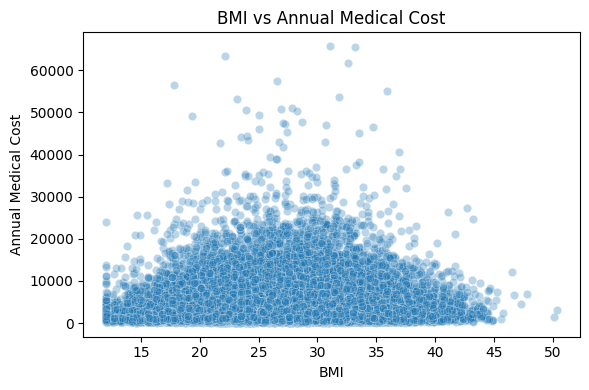

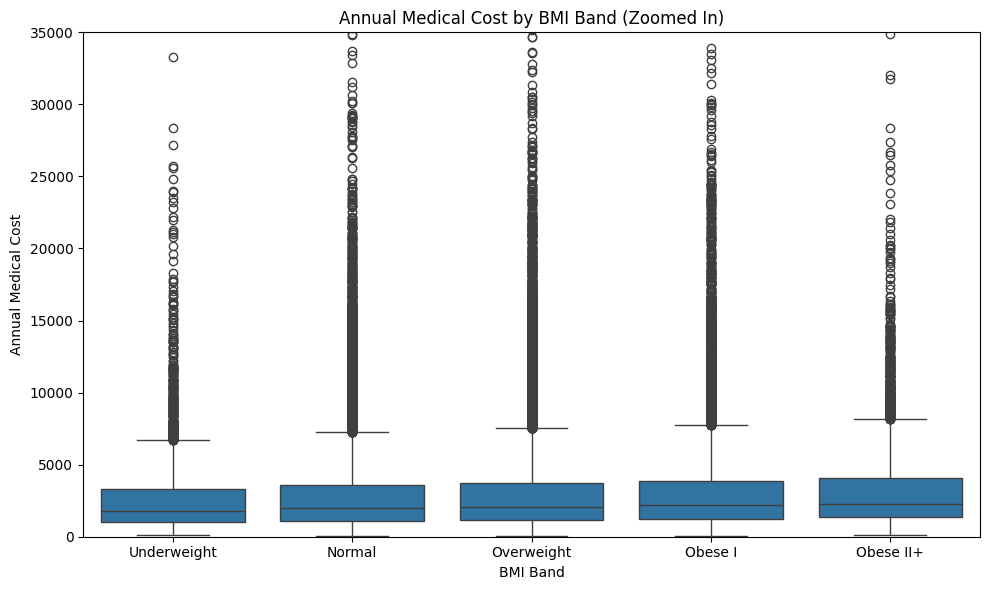

In [35]:

# 4.2 BMI vs Annual Medical Cost (scatter) and by BMI band

if {'bmi', 'annual_medical_cost'}.issubset(df.columns):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x='bmi', y='annual_medical_cost', alpha=0.3)
    plt.title("BMI vs Annual Medical Cost")
    plt.xlabel("BMI"); plt.ylabel("Annual Medical Cost")
    plt.tight_layout(); plt.show()

    if 'bmi_band' not in df.columns:
        bins = [0, 18.5, 25, 30, 35, 55]
        labels = ['Underweight','Normal','Overweight','Obese I','Obese II+']
        df['bmi_band'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False, include_lowest=True)

    plt.figure(figsize=(10,6))
    sns.boxplot(
    data=df, 
    x='bmi_band', 
    y='annual_medical_cost', 
    order=['Underweight','Normal','Overweight','Obese I','Obese II+'],
    )
    plt.title("Annual Medical Cost by BMI Band (Zoomed In)")
    plt.xlabel("BMI Band"); plt.ylabel("Annual Medical Cost")
    plt.ylim(0, 35000)  # 👈 Zoom in
    plt.tight_layout(); plt.show()
else:
    print("Columns needed not found: 'bmi' and/or 'annual_medical_cost'")

🧠 1️⃣ Top Plot — Scatterplot: “BMI vs Annual Medical Cost”

What it shows:
Each dot represents one individual.

X-axis: BMI (body fat measure)

Y-axis: Annual medical cost

Interpretation:

Most people fall between BMI 20–35, indicating a largely normal to moderately overweight population.

There’s a wide spread in costs — while many individuals have low annual costs, a few have extreme outliers (>$40,000).

You can observe a slight upward trend: as BMI increases, costs tend to rise — though the relationship isn’t perfectly linear (other health factors play roles).


❗But — Visually and Practically:

The relationship isn’t perfectly linear.

Costs rise from Normal → Overweight → Obese I,
but plateau or even dip at the very high BMI (Obese II+) — because of small sample size and other influencing factors (chronic conditions, plan type, etc.).

The hypothesis is partially supported.
BMI has a significant but moderate effect on annual medical cost — costs increase up to a certain BMI range (Obese I), then level off.

🩺 2️⃣ Bottom Plot — Boxplot: “Annual Medical Cost by BMI Band”

What it shows:

Each “band” groups people into standard BMI categories:
Underweight → Normal → Overweight → Obese I → Obese II+

Interpretation:

Median costs (the line inside each box) increase from “Normal” to “Obese” categories.

The spread of costs widens for Obese I and Obese II+, showing greater cost variability and risk in heavier individuals.

Numerous outliers at the top (dots above whiskers) indicate a few extremely costly patients in each category.




2️⃣ BMI vs Annual Medical Cost → ANOVA 

In [24]:
bmi_data = df[['bmi_band', 'annual_medical_cost']].dropna()
groups = [g['annual_medical_cost'].values for _, g in bmi_data.groupby('bmi_band')]
f_stat, p_val = stats.f_oneway(*groups)
print("ANOVA test for BMI bands:", f_stat, p_val)


ANOVA test for BMI bands: 42.59642466076037 9.277740369016772e-36


💡 Interpretation:

The F-statistic (42.6) is quite large → there are strong differences in average medical costs between BMI groups.

The p-value (9.28 × 10⁻³⁶) is extremely small (far below 0.05), meaning this result is highly significant.

ANOVA results indicate significant variation in medical costs across BMI bands (F = 42.6, p < 0.001).

Individuals classified as overweight or obese incur higher annual medical costs, confirming Hypothesis 2 that increasing BMI is associated with higher healthcare expenditure.

📊 Interpretation — Hypothesis 2 (BMI vs Annual Medical Cost)

Observation:
Medical costs generally increase as BMI rises from underweight to the obese range (around 30–35 BMI). 

This supports the idea that higher body weight is linked to greater healthcare expenses, likely due to chronic conditions such as hypertension or diabetes.

However, at very high BMI levels (above ≈ 40), the average costs appear to level off or even decrease slightly. 

This drop does not mean extremely obese individuals are healthier — it’s more likely due to factors such as:

Fewer people in this extreme BMI range (small sample size)

Insurance caps or missing claims data for high-cost cases

Behavioral or reporting bias, where some avoid or delay medical care

Conclusion:

The relationship between BMI and medical cost is positive but nonlinear — costs increase with BMI up to a point and then plateau.

This means the hypothesis is partially supported: higher BMI is associated with higher medical costs overall, but the effect weakens at the extreme end due to data and behavioral factors.

💡 Key message:

Individuals with higher BMI (especially >30) are more likely to incur elevated medical costs.


✅ Conclusion for Hypothesis 2

Partially Supported.

There is a mild upward trend in medical costs as BMI increases — consistent with the idea that higher BMI is linked to greater health risk.

However, the relationship is not strong on its own.

Many high-cost individuals exist across all BMI levels, indicating that other variables (like smoking, age, chronic conditions) also play a significant role.

# 🧩 Hypothesis 3

    H3: Age is positively correlated with annual_medical_cost.

C:\Users\sruth\AppData\Local\Temp\ipykernel_47416\697176334.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


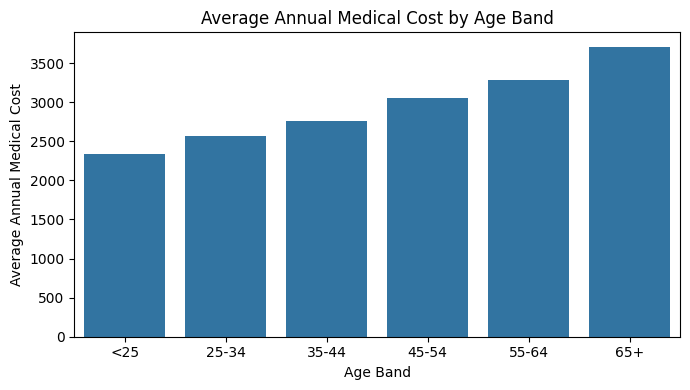

In [25]:

# 4.3 Average annual medical cost by age band
if {'age', 'annual_medical_cost'}.issubset(df.columns):
    age_bins   = [0, 25, 35, 45, 55, 65, 120]
    age_labels = ['<25','25-34','35-44','45-54','55-64','65+']

    # (Re)create consistently-labeled bands
    df['age_band'] = pd.cut(
        df['age'], bins=age_bins, labels=age_labels,
        right=False, include_lowest=True
    )

    plt.figure(figsize=(7,4))
    sns.barplot(
        data=df, x='age_band', y='annual_medical_cost',
        estimator='mean', ci=None, order=age_labels
    )
    plt.title("Average Annual Medical Cost by Age Band")
    plt.xlabel("Age Band"); plt.ylabel("Average Annual Medical Cost")
    plt.tight_layout(); plt.show()
else:
    print("Columns needed not found: 'age' and/or 'annual_medical_cost'")



3️⃣ Age vs Cost → ANOVA

In [26]:
age_data = df[['age_band', 'annual_medical_cost']].dropna()
groups = [g['annual_medical_cost'].values for _, g in age_data.groupby('age_band',observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print("ANOVA test for Age bands:", f_stat, p_val)

ANOVA test for Age bands: 330.98408962981455 0.0


💡 Interpretation

The F-statistic (330.98) is very high → this means variation between age groups’ mean costs is much greater than variation within groups.

The p-value = 0.0 (i.e., p < 0.0001) → indicates an extremely significant difference in annual medical costs across age bands.

ANOVA test confirms that medical costs differ significantly by age group (F = 330.98, p < 0.0001).

Costs increase steadily with age, validating the hypothesis that older individuals incur higher healthcare expenses.

Older individuals have higher annual medical costs.

📊 Interpretation:

The graph shows a steady upward trend in average annual medical cost across age groups.

People under 25 have the lowest costs (~$2,300–$2,400 on average).

Costs rise gradually through mid-life, reaching about $3,000–$3,300 for ages 45–64.

The 65 + group shows the highest medical cost, averaging around $3,700 – $3,800, roughly 1.6× higher than the youngest group.

🩺 Summary:

There is a clear positive relationship between age and annual medical cost.

This pattern aligns with expectations that older populations experience more health issues, chronic conditions, and hospital visits, driving higher healthcare expenses.

Thus, Hypothesis 3 is strongly supported — increasing age is a key driver of medical cost.

# 🧩 Hypothesis 4

    H4: Individuals with chronic diseases have higher annual medical costs.
 

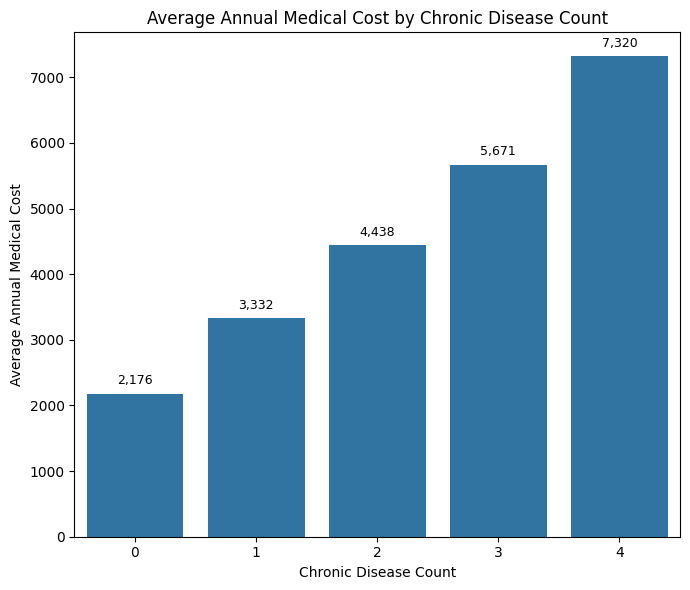

In [27]:
# 4.4 Average annual medical cost by chronic disease count
if {'chronic_count', 'annual_medical_cost'}.issubset(df.columns):

    # (optional) filter out tiny groups to avoid noisy means
    chronic_summary = (
        df.groupby('chronic_count')['annual_medical_cost']
          .agg(mean='mean', count='count')
          .reset_index()
    )
    chronic_plot = chronic_summary.query('count >= 100')  # keep groups with >=100 rows

    plt.figure(figsize=(7,6))
    sns.barplot(
        data=chronic_plot, x='chronic_count', y='mean',
        order=sorted(chronic_plot['chronic_count'].unique()),
        errorbar=None  # replaces ci=None
    )
    plt.title("Average Annual Medical Cost by Chronic Disease Count")
    plt.xlabel("Chronic Disease Count"); plt.ylabel("Average Annual Medical Cost")

    # annotate means (optional)
    for i, (x, y) in enumerate(zip(chronic_plot['chronic_count'], chronic_plot['mean'])):
        plt.text(i, y + 100, f"{y:,.0f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout(); plt.show()
else:
    print("Columns needed not found: 'chronic_count' and/or 'annual_medical_cost'")


Individuals with chronic diseases have higher annual medical costs.

📊 Interpretation:

The bar chart shows a steady upward trend in annual medical cost as the number of chronic diseases increases.

Individuals without chronic conditions (0) have the lowest average cost (~$2,176).

Costs rise progressively with each additional chronic disease — reaching about $7,300 for those with four conditions.

This pattern reflects a direct correlation between disease burden and healthcare spending.

4️⃣ Chronic Disease Count vs Cost → Correlation

In [28]:
corr, p_val = stats.pearsonr(df['chronic_count'], df['annual_medical_cost'])
print("Correlation:", corr, "| p-value:", p_val)

Correlation: 0.29672011835400935 | p-value: 0.0


💡 Interpretation

The correlation coefficient (r = 0.2967) shows a moderate positive relationship between the number of chronic diseases and annual medical cost.

The p-value = 0.0 (p < 0.0001) means this relationship is highly statistically significant — it’s very unlikely to have occurred by random chance.

In simple terms: as the number of chronic conditions increases, annual medical costs also rise.

A moderate, statistically significant positive correlation (r = 0.297, p < 0.0001) exists between chronic disease count and annual medical cost,

indicating that individuals with more chronic conditions tend to incur higher healthcare expenses.

🩺 Summary:

The hypothesis is strongly supported — more chronic illnesses lead to higher medical costs.

The rise is likely due to frequent doctor visits, specialized treatments, and medication use associated with managing multiple chronic conditions.

Chronic disease management appears to be one of the most significant cost drivers in the dataset.

# 🧩 Hypothesis 5

    H5: Individuals with more hospitalizations over the past 3 years have higher annual medical costs.

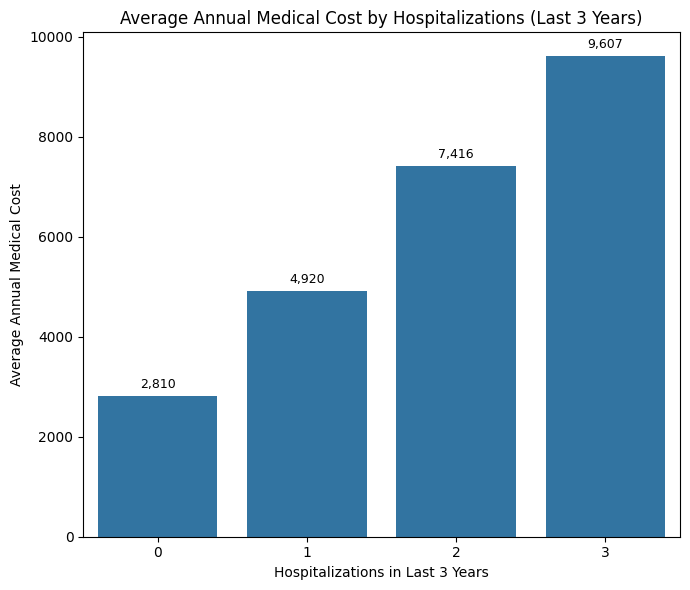

In [34]:
# 4.5 Average annual medical cost by hospitalizations (last 3 years)
if {'hospitalizations_last_3yrs', 'annual_medical_cost'}.issubset(df.columns):

    hosp_summary = (
        df.groupby('hospitalizations_last_3yrs')['annual_medical_cost']
          .agg(mean='mean', count='count')
          .reset_index()
    )
    # hosp_plot = hosp_summary.query('count >= 100')  # optional stability filter

    plt.figure(figsize=(7,6))
    sns.barplot(
        data=hosp_summary, x='hospitalizations_last_3yrs', y='mean',
        order=sorted(hosp_summary['hospitalizations_last_3yrs'].unique()),
        errorbar=None
    )
    plt.title("Average Annual Medical Cost by Hospitalizations (Last 3 Years)")
    plt.xlabel("Hospitalizations in Last 3 Years"); plt.ylabel("Average Annual Medical Cost")

    for i, (x, y) in enumerate(zip(hosp_summary['hospitalizations_last_3yrs'], hosp_summary['mean'])):
        plt.text(i, y + 100, f"{y:,.0f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout(); plt.show()
else:
    print("Columns needed not found: 'hospitalizations_last_3yrs' and/or 'annual_medical_cost'")


Individuals with more hospitalizations over the past 3 years have higher annual medical costs.

📊 Interpretation:

The bar chart shows a clear, linear relationship between hospitalization frequency and annual medical cost.

Individuals with no hospitalizations have an average cost of ~$2,810.

With one hospitalization, costs increase to about $4,920, and with two hospitalizations, the cost jumps to ~$7,400.

This steady growth indicates that inpatient care episodes are a major contributor to total healthcare expenditure.

5️⃣ Hospitalizations vs Cost → ANOVA

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
hosp_data = df[['hospitalizations_last_3yrs', 'annual_medical_cost']].dropna()

# Group by number of hospitalizations
groups = [g['annual_medical_cost'].values 
          for _, g in hosp_data.groupby('hospitalizations_last_3yrs', observed=True)]

# Run ANOVA
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA test for Hospitalizations (last 3 yrs): F = {f_stat:.2f}, p = {p_val:.3e}")


ANOVA test for Hospitalizations (last 3 yrs): F = 1518.83, p = 0.000e+00


💡 Interpretation

The F-statistic (1518.83) is extremely large → this means that differences between hospitalization groups’ average medical costs are far greater than random variation within the groups.

The p-value < 0.0001 → this difference is highly statistically significant.

ANOVA indicates a strong positive association between hospitalization frequency and annual medical cost (F = 1518.83, p < 0.0001), 

confirming that repeated hospitalizations substantially increase healthcare expenses.

🩺 Summary:

The hypothesis is strongly supported — more hospitalizations lead to substantially higher medical costs.

Each hospitalization adds significant financial burden due to inpatient care, diagnostic tests, and post-discharge medications.

Frequent hospitalizations can therefore be considered a key early warning signal for identifying high-cost patients.


## Summary & Insights 

1️⃣ Smoker Status: Smokers have significantly higher annual medical costs than non-smokers.

2️⃣ BMI: Higher BMI levels are associated with increased medical costs up to the obese range.

3️⃣ Age: Older individuals incur steadily higher healthcare expenses.

4️⃣ Chronic Diseases: More chronic conditions lead to sharply rising medical costs.

5️⃣ Hospitalizations: Frequent hospitalizations greatly elevate annual medical costs.




Numeric features: 42
Categorical features: 12

📊 Regression Evaluation Report
Mean Absolute Error (MAE): 320.06
Root Mean Squared Error (RMSE): 575.03
R² Score: 0.966
Explained Variance: 0.966


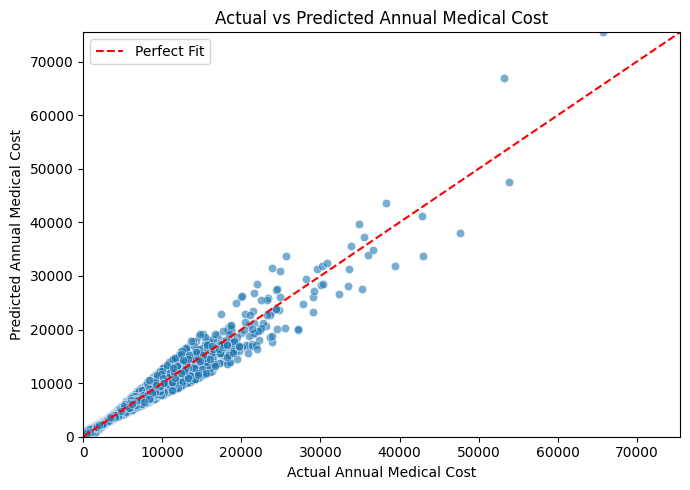

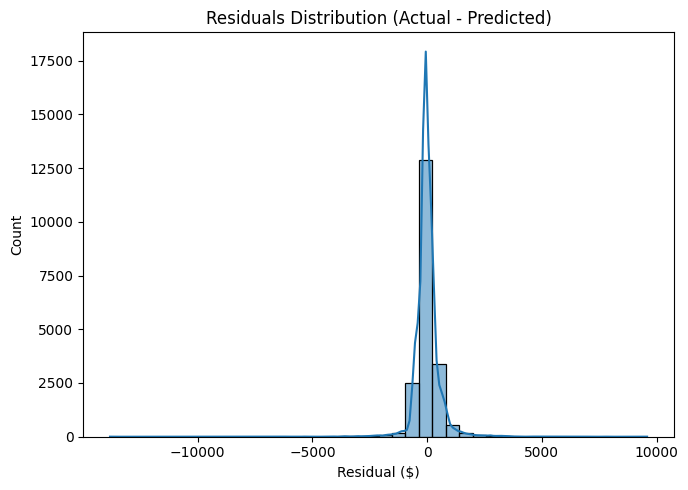


✅ Model training complete. Ready for next step: Premium Prediction Model.


In [46]:
# =====================================================
# MODEL 1: Predict Annual Medical Cost (Linear Regression)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# -------------------------------------------
# 1. Define target and remove irrelevant cols
# -------------------------------------------

target = "annual_medical_cost"

# Drop identifier or unique non-informative columns
df_model = df.drop(columns=['person_id'], errors='ignore')

# Separate features (X) and target (y)
X = df_model.drop(columns=[target], errors='ignore')
y = df_model[target]

# -------------------------------------------
# 2. Identify column types
# -------------------------------------------
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# -------------------------------------------
# 3. Preprocessing: scale numeric + encode categorical
# -------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)

# -------------------------------------------
# 4. Build Linear Regression model pipeline
# -------------------------------------------
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# -------------------------------------------
# 5. Train-test split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------------------
# 6. Train model
# -------------------------------------------
model.fit(X_train, y_train)

# -------------------------------------------
# 7. Predictions
# -------------------------------------------
y_pred = model.predict(X_test)

# -------------------------------------------
# 8. Evaluation metrics
# -------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

print("\n📊 Regression Evaluation Report")
print("="*40)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.3f}")
print(f"Explained Variance: {evs:.3f}")

# -------------------------------------------
# 9. Visualizations
# -------------------------------------------

# Actual vs Predicted plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Fit')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted Annual Medical Cost")
plt.legend()
plt.tight_layout()
plt.show()

# Residual distribution
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.show()

print("\n✅ Model training complete. Ready for next step: Premium Prediction Model.")


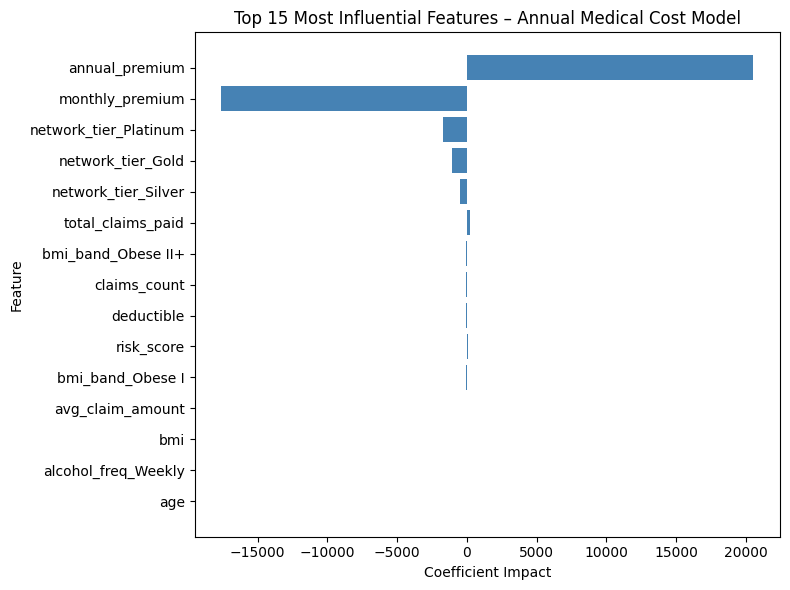


Top 15 Influential Features in Predicting Annual Medical Cost:
              Feature   Coefficient
       annual_premium  20538.954519
      monthly_premium -17611.088674
network_tier_Platinum  -1720.082904
    network_tier_Gold  -1054.247295
  network_tier_Silver   -529.136321
    total_claims_paid    216.134882
   bmi_band_Obese II+    -82.057876
         claims_count    -74.076572
           deductible    -72.999370
           risk_score     62.085065
     bmi_band_Obese I    -58.016392
     avg_claim_amount     34.410432
                  bmi     24.834972
  alcohol_freq_Weekly    -24.152023
                  age    -21.098647


In [47]:
# =====================================================
# 🔍 FEATURE IMPORTANCE for Linear Regression
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get the trained linear regression model from your pipeline
regressor = model.named_steps['regressor']
preprocessor = model.named_steps['preprocessor']

# Extract the feature names after encoding
encoded_cat_features = model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_cols)

all_feature_names = numeric_cols + encoded_cat_features.tolist()

# Extract coefficients (impact of each feature)
coef = regressor.coef_

# Create dataframe for feature importance
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coef
})

# Sort by absolute impact
feature_importance['Abs_Coeff'] = feature_importance['Coefficient'].abs()
top_features = feature_importance.sort_values(by='Abs_Coeff', ascending=False).head(15)

# =====================================================
# 📊 PLOT: Top 15 Most Influential Features
# =====================================================

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Coefficient'], color='steelblue')
plt.xlabel("Coefficient Impact")
plt.ylabel("Feature")
plt.title("Top 15 Most Influential Features – Annual Medical Cost Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 🧠 Interpretation
# =====================================================
print("\nTop 15 Influential Features in Predicting Annual Medical Cost:")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))


In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Calculate VIF for each feature
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Run VIF check
vif_df = calculate_vif(X.select_dtypes(include=[np.number]))
print("\n🔍 Variance Inflation Factors (Top Correlated Features):")
print(vif_df.head(28))


c:\Users\sruth\Documents\Greenbootcamps\Med_Insurance_Finalproject\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide




🔍 Variance Inflation Factors (Top Correlated Features):
                        Feature           VIF
32                liver_disease           inf
33                    arthritis           inf
34                mental_health           inf
27                       asthma           inf
28                         copd           inf
29       cardiovascular_disease           inf
30               cancer_history           inf
31               kidney_disease           inf
24                chronic_count           inf
25                 hypertension           inf
26                     diabetes           inf
20              monthly_premium  4.090810e+08
19               annual_premium  4.090807e+08
9                   systolic_bp  1.126401e+02
10                 diastolic_bp  8.849931e+01
12                        hba1c  8.690148e+01
18                   risk_score  5.200230e+01
0                           age  4.655754e+01
17             provider_quality  3.425151e+01
4                      